# Solving the Sparse Reward Problem

## Part 1. Q-network for Mountain Car (Discrete)

1. Implement DQN, tune it, and demonstrate that the code works.

2. Reward Shaping. Describe and implement an artificial reward function to solve the problem within 2000 episodes.

   You may calculate the reward based on the total energy of the system.

3. Implement either the [Reverse Curriculum](https://bair.berkeley.edu/blog/2017/12/20/reverse-curriculum/) method for the discrete learning task, or [Hindsight Experience Replay](https://openai.com/index/ingredients-for-robotics-research/). (You may use existing libraries or frameworks.)

   Provide a comparison with reward shaping, or draw conclusions about reward engineering and the implemented method.

4. Solve the [MountainCar Continuous](https://gymnasium.farama.org/environments/classic_control/mountain_car_continuous/) environment using any modifications designed to address sparse reward problems, combined with an RL method from stable-baselines3 or other popular implementations.

### 0. Import and helper functions init

In [ ]:
!pip install gymnasium[classic-control] pyvirtualdisplay
!apt-get install -y xvfb python-opengl ffmpeg
!apt-get install ffmpeg freeglut3-dev xvfb
!pip install stable-baselines3
!pip install shimmy>=2.0

In [ ]:
from stable_baselines3.common.base_class import BaseAlgorithm
from stable_baselines3 import HerReplayBuffer, DDPG, DQN, SAC, TD3
from stable_baselines3.her.goal_selection_strategy import GoalSelectionStrategy
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import EvalCallback
from stable_baselines3.common.results_plotter import load_results, ts2xy
import os

from gymnasium import Wrapper
from gymnasium import spaces

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline

import ipywidgets as widgets
from IPython import display
from pyvirtualdisplay import Display
d = Display(visible=0, size=(400, 300))
d.start()

import copy
import torch
from torch.autograd import Variable
from torch import nn
import random
import math
import torchvision.transforms as T
import numpy as np
import time
import gymnasium as gym, math
from gymnasium.utils.save_video import save_video

env = gym.make("MountainCar-v0")

seed = 42

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    env.reset(seed=seed)
    env.action_space.seed(seed)
    env.observation_space.seed(seed)

Helper function for video recording

In [ ]:
import base64
from pathlib import Path

def show_video(model, env):
  done = False
  total_reward = 0

  video_path = 'videos'

  observation, _ = env.reset()
  frames = []

  while not done:
      if isinstance(model, BaseAlgorithm):
          action, _states = model.predict(observation, deterministic=True)
      else:
          q_values = model.predict(observation)
          action = torch.argmax(q_values).item()

      observation, reward, terminated, truncated, _ = env.step(action)
      total_reward += reward
      frames.append(env.render())
      done = terminated or truncated

  save_video(frames, video_path, fps=env.metadata["render_fps"], video_length=len(frames))

  # Close the environment
  env.close()

  # Render recording
  print(f'reward is {total_reward}')
  html = []
  for mp4 in Path(video_path).glob("{}*.mp4".format("")):
      video_b64 = base64.b64encode(mp4.read_bytes())
      html.append(
          """<video alt="{}" autoplay
                  loop controls style="height: 400px;">
                  <source src="data:video/mp4;base64,{}" type="video/mp4" />
              </video>""".format(
              mp4, video_b64.decode("ascii")
          )
      )
  display.display(display.HTML(data="<br>".join(html)))


In [ ]:
def inference(model, env, threshold, episodes=200):
  for i_episode in range(200):
    observation, _ = env.reset()
    rewards = 0
    state = observation

    if (i_episode + 1) % 50 == 0:
        plt.figure(2)
        plt.clf()

        plt.plot([0,i_episode], [threshold, threshold], label="threshold")
        plt.plot(range(0,i_episode), log_total_reward[0:i_episode], label="solution 1")
        plt.xlabel('episode')
        plt.ylabel('episode reward')
        plt.legend()
        plt.title('epsilon={}'.format(epsilon))
        display.clear_output(wait=True)
        display.display(plt.gcf())

    for t in range(STEPS_MAX):
        if isinstance(model, BaseAlgorithm):
            action, _states = model.predict(observation, deterministic=True)
        else:
            q_values = model.predict(observation)
            action = torch.argmax(q_values).item()

        observation, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        rewards += reward
        next_state = observation

        if done:
            log_total_reward[i_episode] = rewards
            log_steps_number[i_episode] = t
            break

        state = next_state
  print("done")

## 1 и 2. DQN + Reward Shaping

In [ ]:
class DQN():
    ''' Deep Q Neural Network class. '''
    def __init__(self, state_dim, action_dim, hidden_dim=16, alpha=0.001):
            self.criterion = nn.MSELoss()
            self.model = nn.Sequential(
                nn.Linear(state_dim, hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, action_dim)
            )
            self.optimizer = torch.optim.Adam(self.model.parameters(), lr=alpha)

            self.losses = []

    def update(self, state, y):
        """Update the weights of the network given a training sample. """
        y_pred = self.model(torch.Tensor(state))
        loss = self.criterion(y_pred, Variable(torch.Tensor(y)))

        self.losses.append(loss.item())

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

    def predict(self, state):
        """ Compute Q values for all actions using the DQL. """
        with torch.no_grad():
            return self.model(torch.Tensor(state))

    def replay(self, size, memory, gamma, tmodel):
      if len(memory) < size:
          return

      batch = random.sample(memory, size)

      batch_t = list(map(list, zip(*batch)))
      states = torch.Tensor(batch_t[0])
      actions = torch.LongTensor(batch_t[1])
      next_states = torch.Tensor(batch_t[2])
      rewards = torch.Tensor(batch_t[3])
      is_done = torch.BoolTensor(batch_t[4])

      is_done_indices = torch.where(is_done==True)[0]

      all_q_values = tmodel.predict(states)
      all_q_values_next = tmodel.predict(next_states)

      all_q_values[range(len(all_q_values)), actions] = rewards + gamma*torch.max(all_q_values_next, axis=1).values

      all_q_values[is_done_indices.tolist(), actions[is_done].tolist()] = rewards[is_done_indices.tolist()]

      self.update(states.tolist(), all_q_values.tolist())


Using the difference between full energies of two states as artificial reward

In [ ]:
def energy(state) :
    x = state[0]
    v = state[1]
    m = 1.0
    g = 0.0025
    h = np.sin((x - (0.5 * np.pi)) + 0.5) + 1.0
    u = m * g * h
    k = 0.5 * v * v
    xmax = 0.6
    vmax = 0.07
    n = 1 / ((m * g * (np.sin((xmax - (0.5 * np.pi)) + 0.5) + 1.0)) + (0.5 * vmax * vmax))
    e = n * (u + k)
    return e

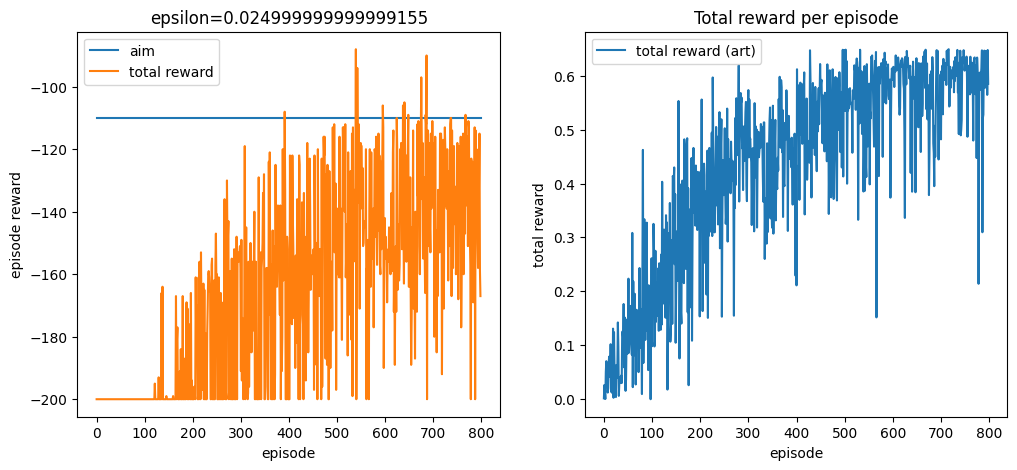

done


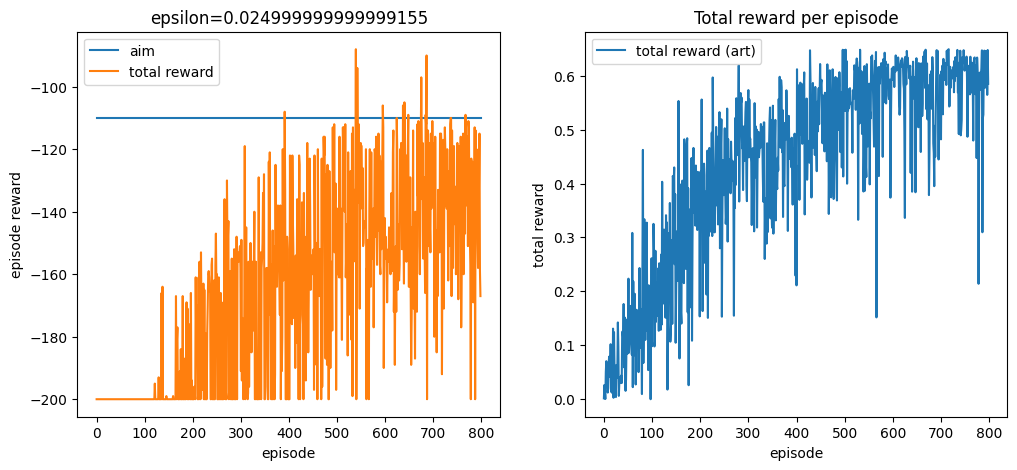

In [ ]:
set_seed(seed)

# Q table
n_states = env.observation_space.shape[0]
n_actions = env.action_space.n # Actions

# Learning Parameters
epsilon = 0.9 # gready threashold
alpha = 1e-4 # learning rate
gamma = 0.99 # reward discount factor

# Gravity
g = 0.0025

# Execution parameters
SHOW_ANIMATION = False
EPISODES_MAX = 800
STEPS_MAX = 500
DESIRED_STEPS = 200

epsilon_decay = np.exp(np.log(0.025/epsilon)/EPISODES_MAX)

# Loggers
log_total_reward = np.zeros(EPISODES_MAX)
log_total_reward_art = np.zeros(EPISODES_MAX)
log_steps_number = np.zeros(EPISODES_MAX)
log_epsilon = np.zeros(EPISODES_MAX)

#
n_hidden = 128
model = DQN(n_states, n_actions, n_hidden, alpha)

#
memory = []
replay_size = 128

# Q-learning
for i_episode in range(EPISODES_MAX):
    state, _ = env.reset()
    rewards = 0
    rewards_art = 0

    log_epsilon[i_episode] = epsilon
    epsilon = epsilon*epsilon_decay

    if (i_episode + 1) % 10 == 0:
        plt.figure(2, figsize=(12, 5))
        plt.clf()

        # ---- Left ----
        ax1 = plt.subplot(1, 2, 1)
        ax1.plot([0, i_episode], [-110, -110], label="aim")
        ax1.plot(range(0, i_episode), log_total_reward[0:i_episode], label="total reward")
        ax1.set_xlabel('episode')
        ax1.set_ylabel('episode reward')
        ax1.set_title('epsilon={}'.format(epsilon))
        ax1.legend()

        # ---- RIGHT ----
        ax2 = plt.subplot(1, 2, 2)
        ax2.plot(range(0, i_episode), log_total_reward_art[0:i_episode], label="total reward (art)")
        ax2.set_xlabel('episode')
        ax2.set_ylabel('total reward')
        ax2.set_title('Total reward per episode')
        ax2.legend()

        display.clear_output(wait=True)
        display.display(plt.gcf())

    for t in range(STEPS_MAX):
        q_values = model.predict(state)

        if np.random.random_sample() < epsilon:
            action = env.action_space.sample()
        else:
            action = torch.argmax(q_values).item()

        observation, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        # reward_art = np.sign(state[1]) * (action - 1)
        reward_art = energy(observation) - energy(state)

        rewards += reward
        rewards_art += reward_art
        next_state = observation
        memory.append((state, action, next_state, reward_art, done))

        q_values_list = q_values.tolist()

        model.replay(replay_size, memory, gamma, model)

        if done:
            log_total_reward[i_episode] = rewards
            log_total_reward_art[i_episode] = rewards_art
            log_steps_number[i_episode] = t
            break

        # Update current state
        state = next_state

print("done")

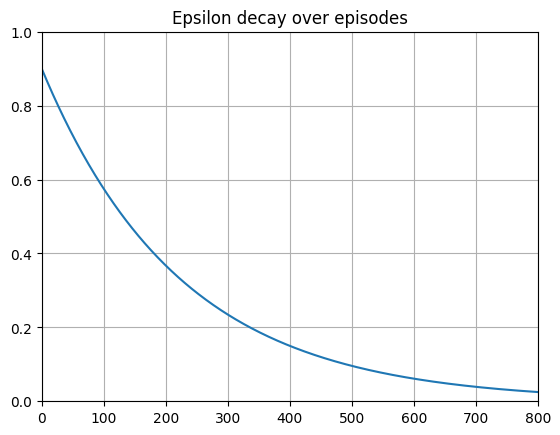

In [ ]:
plt.plot(log_epsilon)
plt.title('Epsilon decay over episodes')
plt.xlim([0, EPISODES_MAX])
plt.ylim([0, 1])
plt.grid()
plt.show()

### Inference

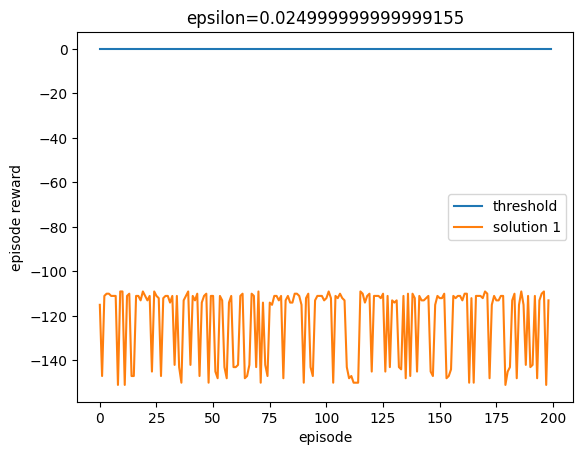

done


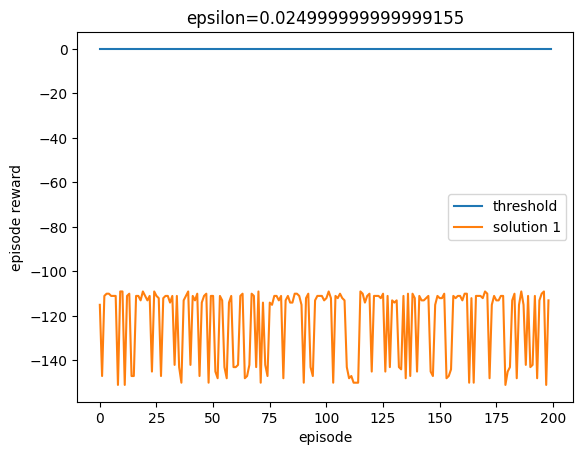

In [ ]:
inference(model, env, threshold=0)

In [ ]:
env = gym.make("MountainCar-v0", render_mode="rgb_array")
show_video(model, env)

reward is -112


## 3. HER or Reverse Curriculum

Implementing Reverse Curriculum Generation (RCG) class

In [ ]:
class RCG():
  def __init__(self, env: gym.Env, expand_step=0.03):
    self.env = env
    self.expand_step = expand_step

    self.goal_pos = env.unwrapped.goal_position

    self.start_low  = self.goal_pos - 0.05
    self.start_high = self.goal_pos

    self.min_pos = env.observation_space.low[0]
    self.max_pos = env.observation_space.high[0]

    self.final_low  = -0.6
    self.final_high = -0.4

  def reset(self):
    reset_options = {
        "low":  self.start_low,
        "high": self.start_high
    }
    return self.env.reset(options=reset_options)

  def goal_achieved(self):

    if self.start_low <= self.final_low:
      self.start_low  = self.final_low
      self.start_high = self.final_high
      return

    new_low = self.start_low - self.expand_step
    new_high = self.start_high - self.expand_step/2

    new_low  = max(new_low,  self.final_low)
    new_high = max(new_high, self.final_high)

    self.start_low  = new_low
    self.start_high = max(new_high, new_low + 0.01)

  def soften(self):
    self.start_low  = min(self.start_low  + 0.01, self.goal_pos - 0.05)
    self.start_high = min(self.start_high + 0.01, self.goal_pos + 0.01)

  def get_start_pos_mean(self):
    return (self.start_low + self.start_high)/2


Using DQN with RCG for training

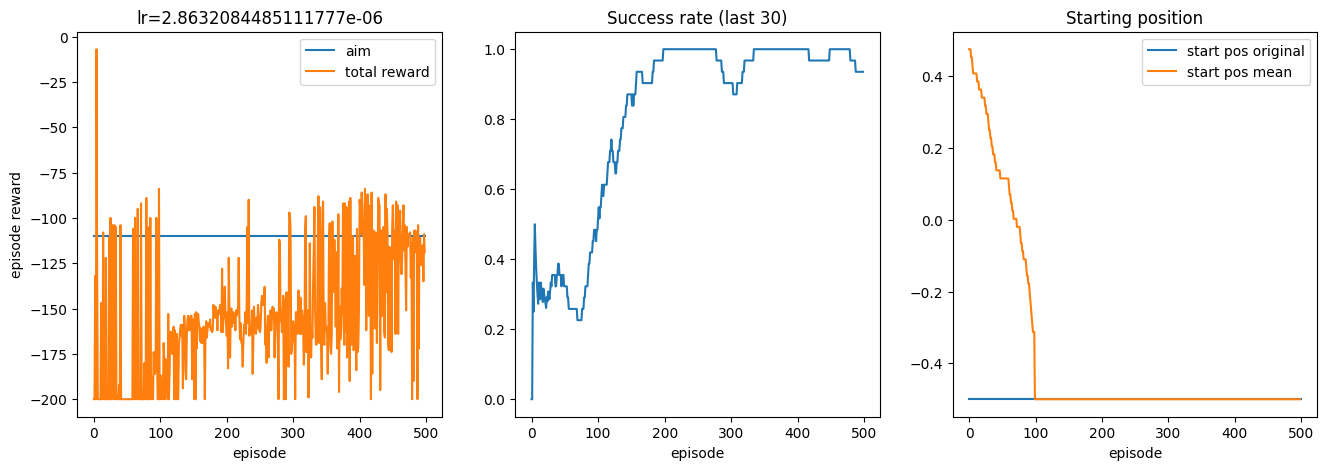

done


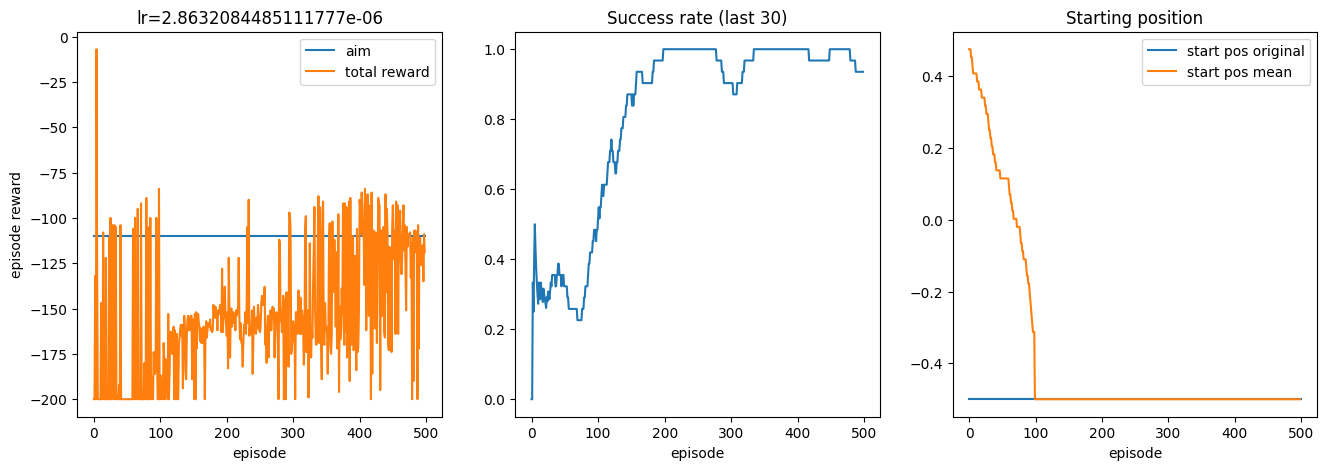

In [ ]:
set_seed(seed)

# Q table
n_states = env.observation_space.shape[0]
n_actions = env.action_space.n # Actions

# Learning Parameters
epsilon = 0.9 # gready threashold
alpha = 5e-4 # learning rate
gamma = 0.99 # reward discount factor

# Execution parameters
SHOW_ANIMATION = False
EPISODES_MAX = 500
STEPS_MAX = 500
DESIRED_STEPS = 200

epsilon_decay = np.exp(np.log(0.025/epsilon)/EPISODES_MAX)

#
n_hidden = 128
model = DQN(n_states, n_actions, n_hidden, alpha)
rcg = RCG(env)

#
memory = []
replay_size = 256

# Loggers
log_total_reward = np.zeros(EPISODES_MAX)
log_steps_number = np.zeros(EPISODES_MAX)
log_epsilon = np.zeros(EPISODES_MAX)
log_success = np.zeros(EPISODES_MAX)
log_start_pos_mean = np.ones(EPISODES_MAX) * rcg.get_start_pos_mean()

# Q-learning
for i_episode in range(EPISODES_MAX):

    log_epsilon[i_episode] = epsilon
    epsilon = epsilon*epsilon_decay

    state, _ = rcg.reset()
    rewards = 0
    success = False

    if (i_episode + 1) % 10 == 0:
        plt.figure(2, figsize=(16, 5))
        plt.clf()

        ax1 = plt.subplot(1, 3, 1)
        ax1.plot([0, i_episode], [-110, -110], label="aim")
        ax1.plot(range(0, i_episode), log_total_reward[0:i_episode], label="total reward")
        ax1.set_xlabel('episode')
        ax1.set_ylabel('episode reward')
        ax1.set_title('lr={}'.format(alpha))
        ax1.legend()

        ax2 = plt.subplot(1, 3, 2)
        rates = []

        for i in range(len(log_success)):
            start = max(i - 30, 0)
            rates.append(np.mean(log_success[start:i+1]))

        ax2.plot(range(0, i_episode), rates[0:i_episode])
        ax2.set_xlabel('episode')
        ax2.set_title('Success rate (last 30)')

        ax3 = plt.subplot(1, 3, 3)
        ax3.plot([0, i_episode], [-0.5, -0.5], label="start pos original")
        ax3.plot(range(0, i_episode), log_start_pos_mean[0:i_episode], label="start pos mean")
        ax3.set_xlabel('episode')
        ax3.set_title('Starting position')
        ax3.legend()

        display.clear_output(wait=True)
        display.display(plt.gcf())

        alpha *= 0.9

    for t in range(STEPS_MAX):
        q_values = model.predict(state)

        if np.random.random_sample() < epsilon:
            action = env.action_space.sample()
        else:
            action = torch.argmax(q_values).item()

        observation, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        rewards += reward
        next_state = observation
        memory.append((state, action, next_state, reward, done))

        q_values_list = q_values.tolist()

        model.replay(replay_size, memory, gamma, model)

        if next_state[0] >= rcg.goal_pos:
            success = True

        if done:
            log_total_reward[i_episode] = rewards
            log_steps_number[i_episode] = t
            log_success[i_episode] = 1 if success else 0
            log_start_pos_mean[i_episode] = rcg.get_start_pos_mean()
            break

        # Update current state
        state = next_state

    if success:
        rcg.goal_achieved()
    else:
        # If no progress:
        if i_episode > 20 and np.mean(log_success[i_episode-20:i_episode]) < 0.1:
            rcg.soften()

print("done")

### Inerence

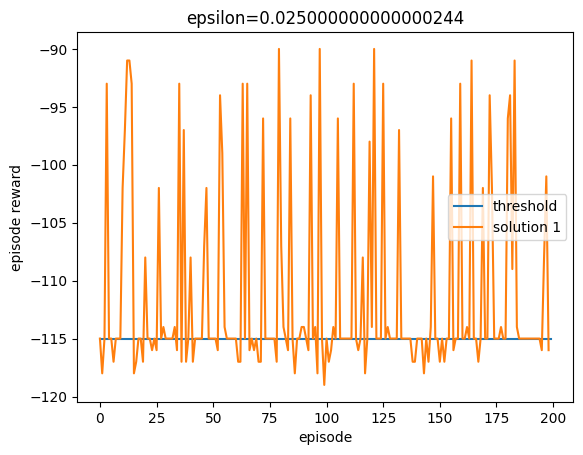

done


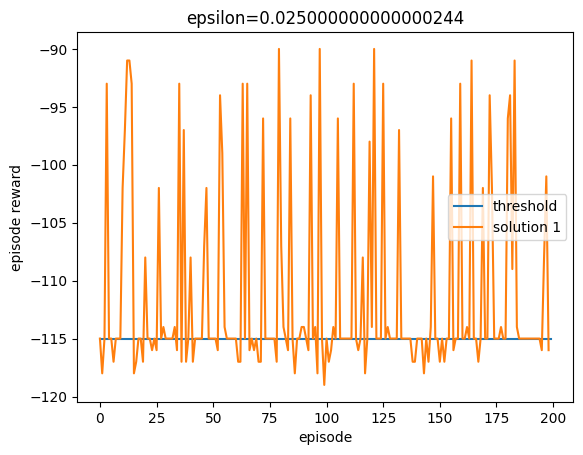

In [ ]:
inference(model, env, -115)

In [ ]:
env = gym.make("MountainCar-v0", render_mode="rgb_array")
show_video(model, env)

reward is -93


We can see that on this task, RCG trains less stably (during training and with a leftward shift of the starting position, the agent overfits to always starting the episode by moving left for acceleration, and when approaching the original starting position, this tactic stops working consistently). However, in terms of final performance, it surpasses Reward Shaping. I would conjecture that training Reward Shaping for slightly longer would eventually yield comparable results. It is worth noting that RCG is primarily designed for tasks where reward shaping is difficult to engineer, so for this particular task, I believe Reward Shaping is more preferable.

## 4. MountainCar Continuous SAC+HER

Now let's try HER algo. I'm using [`stable_baselines3`](https://stable-baselines3.readthedocs.io/en/master/modules/her.html) implementation. It reuires a GoalEnv, which MountainCarContinuous is not, so a GoalEnvWrapper was created

In [ ]:
class GoalEnvWrapper(Wrapper):

    def __init__(self, env, goal_position=0.5, goal_velocity=0.0):
        super().__init__(env)

        self.original_obs_space = env.observation_space

        self.observation_space = spaces.Dict({
            "observation": self.original_obs_space,
            "achieved_goal": self.original_obs_space,
            "desired_goal": self.original_obs_space
        })

        self.goal = np.array([goal_position, goal_velocity], dtype=np.float32)

    def reset(self, seed=None, options=None):
        obs, info = self.env.reset(seed=seed, options=options)

        observation = {
            "observation": obs.copy(),
            "achieved_goal": obs.copy(),
            "desired_goal": self.goal.copy()
        }

        return observation, info

    def step(self, action):
        obs, _, terminated, truncated, info = self.env.step(action)

        observation = {
            "observation": obs.copy(),
            "achieved_goal": obs.copy(),
            "desired_goal": self.goal.copy()
        }

        # Success signal for HER
        info["is_success"] = self.compute_success(obs, self.goal)

        # Reward from original task
        action_penalty = -0.1 * np.square(action).sum()

        # Goal-based reward (HER-compatible)
        goal_reward = self.compute_reward(obs, self.goal, info)

        reward = action_penalty + goal_reward

        return observation, reward, terminated, truncated, info

    def compute_reward(self, achieved_goal, desired_goal, info):
        # achieved_goal, desired_goal shape: (batch, goal_dim) OR (goal_dim,)
        success = np.abs(achieved_goal[..., 0] - desired_goal[..., 0]) < 0.05
        return success.astype(np.float32) * 100.0

    def compute_terminated(self, achieved_goal, desired_goal, info):
        # Check if goal is reached
        position_tolerance = 0.05
        return abs(achieved_goal[0] - desired_goal[0]) < position_tolerance

    def compute_truncated(self, achieved_goal, desired_goal, info):
        return False

    def compute_success(self, achieved_goal, desired_goal):
      return np.abs(achieved_goal[0] - desired_goal[0]) < 0.05


def make_env(seed, log_dir=None):
    env = GoalEnvWrapper(gym.make("MountainCarContinuous-v0"))
    if log_dir is not None:
        env = Monitor(env, log_dir)
    env.reset(seed=seed)
    env.action_space.seed(seed)
    return env


As the base RL algorithm for this task, we can only use methods designed for continuous action spaces (Box), namely DDPG, TD3, PPO, TRPO, A2C, SAC, etc. (see Box [here](https://stable-baselines3.readthedocs.io/en/master/guide/algos.html)). Initially, I wanted to use simple DDPG, but it persistently failed to converge without reward shaping, so I chose SAC instead

In [ ]:
set_seed(seed)

train_env = make_env(seed, "logs/train/")

eval_env  = make_env(seed + 1, "logs/eval/")

eval_callback = EvalCallback(
    eval_env,
    best_model_save_path="logs/best_model/",
    log_path="logs/eval/",
    eval_freq=30_000,
    n_eval_episodes=10,
    deterministic=True,
    render=False,
)

model_class = SAC

def exp_lr_schedule(initial_lr=2e-3, decay_rate=0.997):
    def lr(progress_remaining):
        step = 1.0 - progress_remaining
        return initial_lr * (decay_rate ** (step * 1_000))
    return lr


model = model_class(
    "MultiInputPolicy",
    train_env,
    seed=seed,
    replay_buffer_class=HerReplayBuffer,
    replay_buffer_kwargs=dict(
        n_sampled_goal=4,
        goal_selection_strategy="future",
    ),
    verbose=1,
    learning_rate=exp_lr_schedule(),
    policy_kwargs=dict(
        net_arch=[256, 256, 256],
    ),
    learning_starts=1000,
    train_freq=50,
)

model.learn(5e5, log_interval=10, callback=eval_callback)

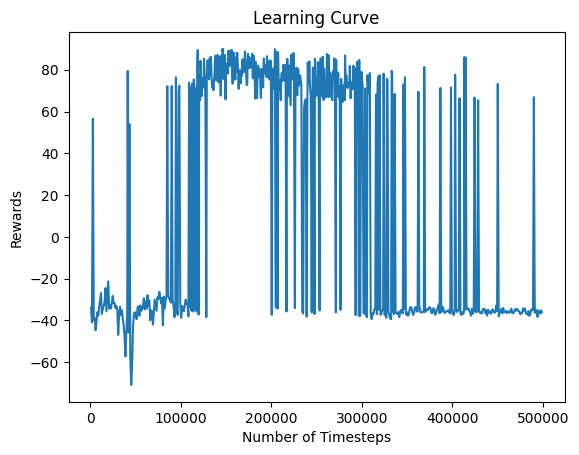

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
def moving_average(values, window):
    """
    Smooth values by doing a moving average
    :param values: (numpy array)
    :param window: (int)
    :return: (numpy array)
    """
    weights = np.repeat(1.0, window) / window
    return np.convolve(values, weights, "valid")


def plot_results(log_folder, title="Learning Curve"):
    """
    plot the results

    :param log_folder: (str) the save location of the results to plot
    :param title: (str) the title of the task to plot
    """
    x, y = ts2xy(load_results(log_folder), "timesteps")
    y = moving_average(y, window=1)
    # Truncate x
    x = x[len(x) - len(y) :]

    fig = plt.figure(title)
    plt.plot(x, y)
    plt.xlabel("Number of Timesteps")
    plt.ylabel("Rewards")
    plt.title(title)
    plt.show()

plot_results("logs/train")

Training ran for 640 episodes, but judging by the learning curve and logs, we could have stopped at around 250 episodes. Precisely for cases of such unstable training, an `eval_callback` was implemented to save the best model during training

Let's download it:

In [ ]:
loading_path = os.path.join('logs/best_model/best_model.zip')
model = SAC.load(loading_path, 
                 seed=model.seed, 
                 env=model.env, 
                 custom_objects={'observation_space': model.observation_space, 
                                 'action_space': model.action_space})

In [ ]:
mean_reward, std_reward = evaluate_policy(model, eval_env, n_eval_episodes=50, warn=False)

print(f"mean_reward: {mean_reward:.2f} +/- {std_reward:.2f}")

mean_reward: 96.80 +/- 0.43


Using the `evaluate_policy` function built into stable_baselines3 over 50 episodes, we obtain a mean reward of 96.8 with a standard deviation of 0.43. Let's also verify this using our custom `inference` function.

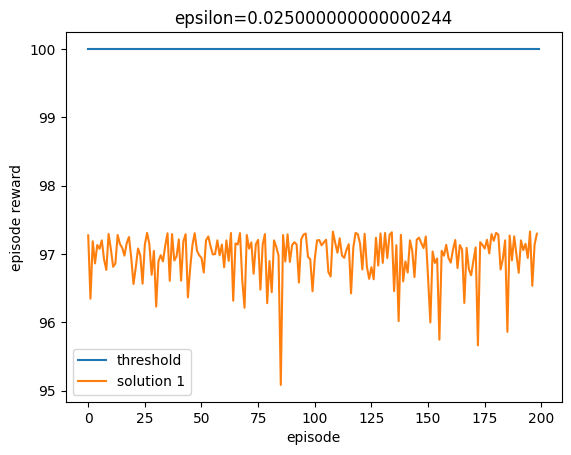

done


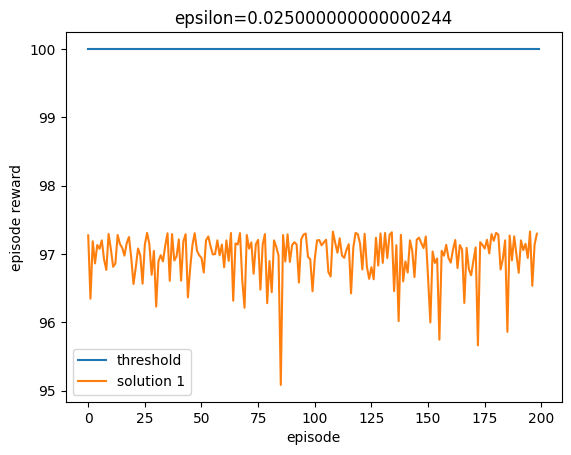

In [ ]:
inference(model, eval_env, 100)

In [ ]:
show_video(model, GoalEnvWrapper(gym.make("MountainCarContinuous-v0", render_mode="rgb_array")))

reward is 97.25767517089844
